In [1]:
import os
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [3]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [4]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image[16:224, 8:232, :]

    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError("No foreground voxels found")

    upper = np.percentile(image[foreground], 99.9)

    image = np.clip(image, 0, upper)

    image = image / upper

    image[~foreground] = 0

    return image.astype(np.float32)

In [5]:
def preprocess_mask(mask):
    # Expected original BraTS shape
    if mask.shape != (240, 240, 155):
        raise ValueError(f"Unexpected mask shape: {mask.shape}")

    # Apply exactly the same spatial crop as T2f
    mask = mask[16:224, 8:232, :]

    # Apply exactly the same z-padding as T2f
    mask = np.pad(
        mask,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    return mask.astype(np.int64)

In [6]:
def calculate_tumour_entropy(image, mask, num_bins=256):
    # Whole tumour = all non-zero tumour labels
    tumour_region = mask > 0

    if not np.any(tumour_region):
        raise ValueError("No tumour voxels found")

    tumour_values = image[tumour_region]

    # T2f has already been normalized to [0, 1]
    tumour_values = np.clip(tumour_values, 0.0, 1.0)

    hist, _ = np.histogram(
        tumour_values,
        bins=num_bins,
        range=(0.0, 1.0),
        density=False
    )

    probabilities = hist.astype(np.float64)
    probabilities = probabilities / probabilities.sum()

    probabilities = probabilities[probabilities > 0]

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return np.float32(entropy)

In [7]:
from torch.utils.data import Dataset, DataLoader

class BraTSDataset(Dataset):
    def __init__(self, subjects, data_dir):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subject = self.subjects[idx]
        subject_path = os.path.join(self.data_dir, subject)

        files = os.listdir(subject_path)

        t2f_file = [f for f in files if "t2f" in f.lower()][0]
        seg_file = [f for f in files if "seg" in f.lower()][0]

        # Load T2f
        image = nib.load(
            os.path.join(subject_path, t2f_file)
        ).get_fdata()

        # Load segmentation
        mask = nib.load(
            os.path.join(subject_path, seg_file)
        ).get_fdata()

        # Apply preprocessing
        image = preprocess_t2f(image)
        mask = preprocess_mask(mask)

        # Calculate whole-tumour Shannon entropy
        entropy = calculate_tumour_entropy(
            image,
            mask
        )

        # Convert to tensors
        image = torch.from_numpy(
            image
        ).float().unsqueeze(0)

        mask = torch.from_numpy(
            mask
        ).long().unsqueeze(0)

        entropy = torch.tensor(
            entropy,
            dtype=torch.float32
        )

        return {
            "image": image,
            "mask": mask,
            "heterogeneity": entropy,
            "subject": subject
        }

In [8]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

In [9]:
class VAEBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU(),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)

In [10]:
class VAEEncoder3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.enc1 = VAEBlock3D(
            in_channels,
            base_channels
        )

        self.down1 = nn.Conv3d(
            base_channels,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.enc2 = VAEBlock3D(
            base_channels * 2,
            base_channels * 2
        )

        self.down2 = nn.Conv3d(
            base_channels * 2,
            base_channels * 4,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bottleneck = VAEBlock3D(
            base_channels * 4,
            base_channels * 4
        )

        self.to_mu = nn.Conv3d(
            base_channels * 4,
            latent_channels,
            kernel_size=1
        )

        self.to_logvar = nn.Conv3d(
            base_channels * 4,
            latent_channels,
            kernel_size=1
        )

    def forward(self, x):

        x = self.enc1(x)
        x = self.down1(x)

        x = self.enc2(x)
        x = self.down2(x)

        x = self.bottleneck(x)

        mu = self.to_mu(x)
        logvar = self.to_logvar(x)

        return mu, logvar

In [11]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [12]:
class VAEDecoder3D(nn.Module):
    def __init__(
        self,
        out_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.from_latent = nn.Conv3d(
            latent_channels,
            base_channels * 4,
            kernel_size=3,
            padding=1
        )

        self.dec2 = VAEBlock3D(
            base_channels * 4,
            base_channels * 4
        )

        self.up2 = nn.ConvTranspose3d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dec1 = VAEBlock3D(
            base_channels * 2,
            base_channels * 2
        )

        self.up1 = nn.ConvTranspose3d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.final_block = VAEBlock3D(
            base_channels,
            base_channels
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, z):

        x = self.from_latent(z)

        x = self.dec2(x)
        x = self.up2(x)

        x = self.dec1(x)
        x = self.up1(x)

        x = self.final_block(x)
        x = self.output_conv(x)

        x = torch.sigmoid(x)

        return x

In [13]:
class VAE3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.encoder = VAEEncoder3D(
            in_channels=in_channels,
            base_channels=base_channels,
            latent_channels=latent_channels
        )

        self.decoder = VAEDecoder3D(
            out_channels=out_channels,
            base_channels=base_channels,
            latent_channels=latent_channels
        )

    def forward(self, x):
        mu, logvar = self.encoder(x)

        z = reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decoder(z)

        return reconstruction, mu, logvar, z

In [15]:
def vae_loss_v3(
    reconstruction,
    target,
    mu,
    logvar,
    kl_weight=1e-6,
    multiscale_weight=0.1
):
    # Full-resolution L1 reconstruction loss
    recon_loss = F.l1_loss(
        reconstruction,
        target
    )

    # Half-resolution structural loss
    recon_half = F.avg_pool3d(
        reconstruction,
        kernel_size=2,
        stride=2
    )

    target_half = F.avg_pool3d(
        target,
        kernel_size=2,
        stride=2
    )

    # Quarter-resolution structural loss
    recon_quarter = F.avg_pool3d(
        reconstruction,
        kernel_size=4,
        stride=4
    )

    target_quarter = F.avg_pool3d(
        target,
        kernel_size=4,
        stride=4
    )

    half_loss = F.l1_loss(
        recon_half,
        target_half
    )

    quarter_loss = F.l1_loss(
        recon_quarter,
        target_quarter
    )

    multiscale_loss = (
        0.5 * half_loss
        + 0.5 * quarter_loss
    )

    # KL divergence
    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    # Total loss
    total_loss = (
        recon_loss
        + multiscale_weight * multiscale_loss
        + kl_weight * kl_loss
    )

    return (
        total_loss,
        recon_loss,
        kl_loss,
        multiscale_loss
    )

In [16]:
def train_vae_v3(
    model,
    train_loader,
    epochs,
    optimizer,
    device,
    checkpoint_dir="vae_x4_v3_checkpoints",
    kl_weight=1e-6,
    multiscale_weight=0.1,
    start_epoch=10
):
    import os

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    loss_history = []
    recon_history = []
    kl_history = []
    multiscale_history = []

    for local_epoch in range(epochs):

        # Continue numbering from the original VAE
        current_epoch = start_epoch + local_epoch + 1

        model.train()

        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_multiscale = 0.0

        for batch_idx, batch in enumerate(train_loader):

            x = batch["image"].to(device)

            optimizer.zero_grad()

            reconstruction, mu, logvar, z = model(x)

            (
                loss,
                recon_loss,
                kl_loss,
                multiscale_loss
            ) = vae_loss_v3(
                reconstruction=reconstruction,
                target=x,
                mu=mu,
                logvar=logvar,
                kl_weight=kl_weight,
                multiscale_weight=multiscale_weight
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
            epoch_multiscale += multiscale_loss.item()

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"Epoch {current_epoch} | "
                    f"Batch {batch_idx + 1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.6f} | "
                    f"Recon: {recon_loss.item():.6f} | "
                    f"KL: {kl_loss.item():.6f} | "
                    f"Multi-scale: {multiscale_loss.item():.6f}"
                )

        avg_loss = (
            epoch_loss / len(train_loader)
        )

        avg_recon = (
            epoch_recon / len(train_loader)
        )

        avg_kl = (
            epoch_kl / len(train_loader)
        )

        avg_multiscale = (
            epoch_multiscale / len(train_loader)
        )

        loss_history.append(avg_loss)
        recon_history.append(avg_recon)
        kl_history.append(avg_kl)
        multiscale_history.append(avg_multiscale)

        print(
            f"Epoch {current_epoch} completed | "
            f"Loss: {avg_loss:.6f} | "
            f"Recon: {avg_recon:.6f} | "
            f"KL: {avg_kl:.6f} | "
            f"Multi-scale: {avg_multiscale:.6f}"
        )

        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"vae_v3_epoch_{current_epoch:03d}.pt"
        )

        torch.save(
            {
                "epoch": current_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": avg_loss,
                "recon_loss": avg_recon,
                "kl_loss": avg_kl,
                "multiscale_loss": avg_multiscale,
                "kl_weight": kl_weight,
                "multiscale_weight": multiscale_weight
            },
            checkpoint_path
        )

        print(
            "Saved:",
            checkpoint_path
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_loss_history.npy"
            ),
            np.array(loss_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_recon_history.npy"
            ),
            np.array(recon_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_kl_history.npy"
            ),
            np.array(kl_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_multiscale_history.npy"
            ),
            np.array(multiscale_history)
        )

    return (
        loss_history,
        recon_history,
        kl_history,
        multiscale_history
    )

In [17]:
def load_vae_checkpoint(
    model,
    optimizer,
    path,
    device
):
    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    loaded_epoch = checkpoint["epoch"]

    print(
        f"Loaded VAE checkpoint from epoch {loaded_epoch}"
    )

    return loaded_epoch

In [18]:
@torch.no_grad()
def reconstruct_vae(
    model,
    image,
    device
):
    model.eval()

    image = image.to(device)

    reconstruction, mu, logvar, z = model(image)

    return reconstruction

In [19]:
timesteps = 1000

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, timesteps)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

In [20]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        embeddings = math.log(10000) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )

        embeddings = t[:, None] * embeddings[None, :]

        embeddings = torch.cat(
            (embeddings.sin(), embeddings.cos()),
            dim=1
        )

        return embeddings

In [21]:
class ResBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv3d(
            in_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.conv2 = nn.Conv3d(
            out_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:
            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        time_emb = self.time_mlp(t)
        time_emb = time_emb[:, :, None, None, None]

        h = h + time_emb

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.residual(x)

In [22]:
class DownBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.resblock = ResBlock3D(
            in_channels,
            out_channels,
            time_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t):
        h = self.resblock(x, t)

        down = self.downsample(h)

        return h, down


class UpBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.resblock = ResBlock3D(
            out_channels + skip_channels,
            out_channels,
            time_dim
        )

    def forward(self, x, skip, t):
        x = self.upsample(x)

        # Match spatial size to the skip connection.
        # Required because latent dimensions such as 26 -> 13 -> 6
        # cannot be exactly restored by x2 transposed convolution.
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="trilinear",
                align_corners=False
            )

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.resblock(
            x,
            t
        )

        return x

In [23]:
def prepare_latent_mask(mask, latent_size=(52, 56, 40)):
    """
    Convert BraTS integer mask to 3-channel one-hot mask
    and downsample it to latent spatial resolution.

    Input:
        mask: [B, 1, 208, 224, 160]

    Output:
        latent_mask: [B, 3, 26, 28, 20]
    """

    mask = mask.long().squeeze(1)

    # Tumour classes 1, 2, 3
    mask_onehot = torch.stack(
        [
            (mask == 1),
            (mask == 2),
            (mask == 3)
        ],
        dim=1
    ).float()

    latent_mask = F.interpolate(
        mask_onehot,
        size=latent_size,
        mode="nearest"
    )

    return latent_mask

In [24]:
class ConditionalLatentUNet3D(nn.Module):
    def __init__(
        self,
        latent_channels=4,
        mask_channels=3,
        base_channels=16,
        time_dim=128
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.heterogeneity_embedding = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        total_in_channels = latent_channels + mask_channels

        self.input_conv = nn.Conv3d(
            total_in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid = ResBlock3D(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            latent_channels,
            kernel_size=1
        )

    def forward(
        self,
        z,
        t,
        latent_mask,
        heterogeneity
    ):
        # Combine noisy latent + spatial mask condition
        z = torch.cat(
            [z, latent_mask],
            dim=1
        )

        # Timestep embedding
        t_emb = self.time_embedding(t)

        # Heterogeneity embedding
        heterogeneity = heterogeneity.float().view(-1, 1)

        h_emb = self.heterogeneity_embedding(
            heterogeneity
        )

        condition_emb = t_emb + h_emb

        # Latent UNet
        z = self.input_conv(z)

        skip1, z = self.down1(
            z,
            condition_emb
        )

        skip2, z = self.down2(
            z,
            condition_emb
        )

        z = self.mid(
            z,
            condition_emb
        )

        z = self.up2(
            z,
            skip2,
            condition_emb
        )

        z = self.up1(
            z,
            skip1,
            condition_emb
        )

        z = self.output_conv(z)

        return z

In [25]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    device = x0.device

    sqrt_alpha_cumprod_device = sqrt_alphas_cumprod.to(device)
    sqrt_one_minus_alpha_cumprod_device = (
        sqrt_one_minus_alphas_cumprod.to(device)
    )

    sqrt_alpha_hat = (
        sqrt_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    sqrt_one_minus_alpha_hat = (
        sqrt_one_minus_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    xt = (
        sqrt_alpha_hat * x0
        + sqrt_one_minus_alpha_hat * noise
    )

    return xt, noise

In [26]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }, path)


def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return checkpoint["epoch"]

In [27]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

vae_v3 = VAE3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    latent_channels=4
).to(device)

checkpoint = torch.load(
    "vae_x4_checkpoints/vae_epoch_010.pt",
    map_location=device
)

vae_v3.load_state_dict(
    checkpoint["model_state_dict"]
)

vae_v3.eval()

print(
    "Loaded original x4 VAE epoch:",
    checkpoint["epoch"]
)

Loaded original x4 VAE epoch: 10


In [28]:
optimizer_v3 = torch.optim.Adam(
    vae_v3.parameters(),
    lr=1e-5
)

(
    v3_loss_history,
    v3_recon_history,
    v3_kl_history,
    v3_multiscale_history
) = train_vae_v3(
    model=vae_v3,
    train_loader=train_loader,
    epochs=5,
    optimizer=optimizer_v3,
    device=device,
    checkpoint_dir="vae_x4_v3_checkpoints",
    kl_weight=1e-6,
    multiscale_weight=0.1,
    start_epoch=10
)

Epoch 11 | Batch 10/1000 | Loss: 0.006567 | Recon: 0.006295 | KL: 2.610449 | Multi-scale: 0.002692


Epoch 11 | Batch 20/1000 | Loss: 0.006557 | Recon: 0.006271 | KL: 2.661380 | Multi-scale: 0.002841


Epoch 11 | Batch 30/1000 | Loss: 0.008777 | Recon: 0.008428 | KL: 2.704016 | Multi-scale: 0.003467


Epoch 11 | Batch 40/1000 | Loss: 0.007276 | Recon: 0.006988 | KL: 2.622918 | Multi-scale: 0.002849


Epoch 11 | Batch 50/1000 | Loss: 0.005806 | Recon: 0.005573 | KL: 2.750749 | Multi-scale: 0.002304


...

Epoch 15 | Batch 960/1000 | Loss: 0.005671 | Recon: 0.005458 | KL: 2.976151 | Multi-scale: 0.002102


Epoch 15 | Batch 970/1000 | Loss: 0.008982 | Recon: 0.008640 | KL: 3.055732 | Multi-scale: 0.003391


Epoch 15 | Batch 980/1000 | Loss: 0.003680 | Recon: 0.003475 | KL: 2.942686 | Multi-scale: 0.002025


Epoch 15 | Batch 990/1000 | Loss: 0.003943 | Recon: 0.003729 | KL: 2.925768 | Multi-scale: 0.002115


Epoch 15 | Batch 1000/1000 | Loss: 0.005636 | Recon: 0.005414 | KL: 2.992356 | Multi-scale: 0.002188
Epoch 15 completed | Loss: 0.006098 | Recon: 0.005855 | KL: 2.993494 | Multi-scale: 0.002394
Saved: vae_x4_v3_checkpoints/vae_v3_epoch_015.pt


Device: cuda
Loaded VAE epoch: 15
Subject: BraTS-GLI-00240-000
Input shape: torch.Size([1, 1, 208, 224, 160])
Input range: 0.0 1.0
Latent shape: torch.Size([1, 4, 52, 56, 40])
Reconstruction shape: torch.Size([1, 1, 208, 224, 160])
Reconstruction range: 2.5166588919160043e-14 0.9717290997505188

Reconstruction metrics
L1: 0.00606658635661006
MSE: 0.00037664154660888016
PSNR: 40.2613176681096 dB
Foreground L1: 0.00606658635661006
Selected axial slice: 0


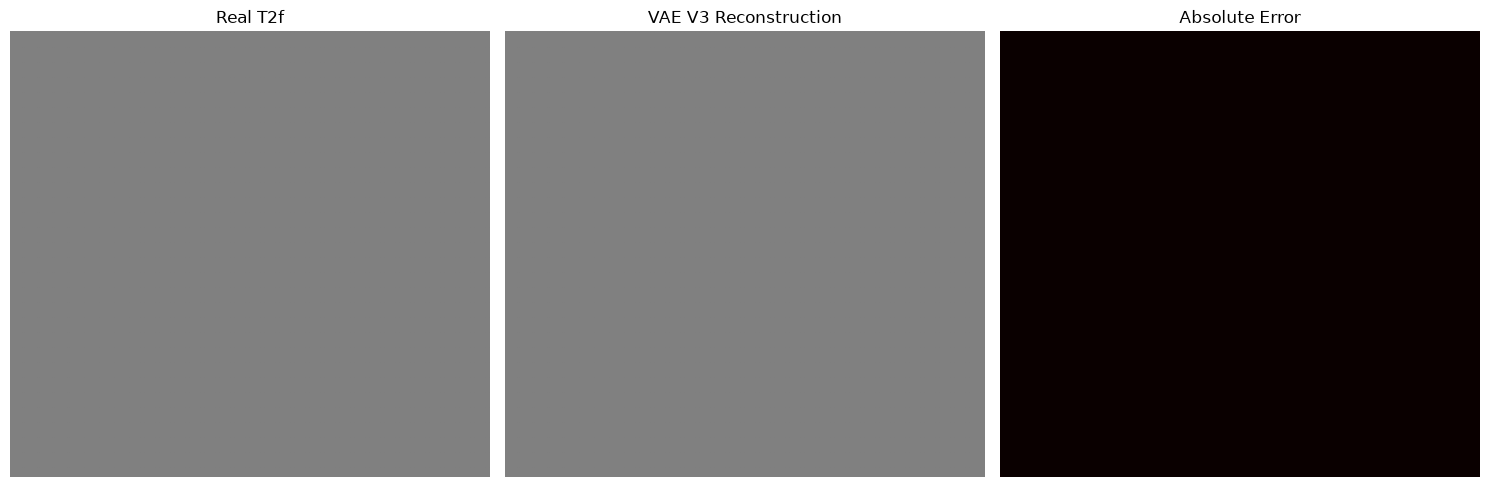

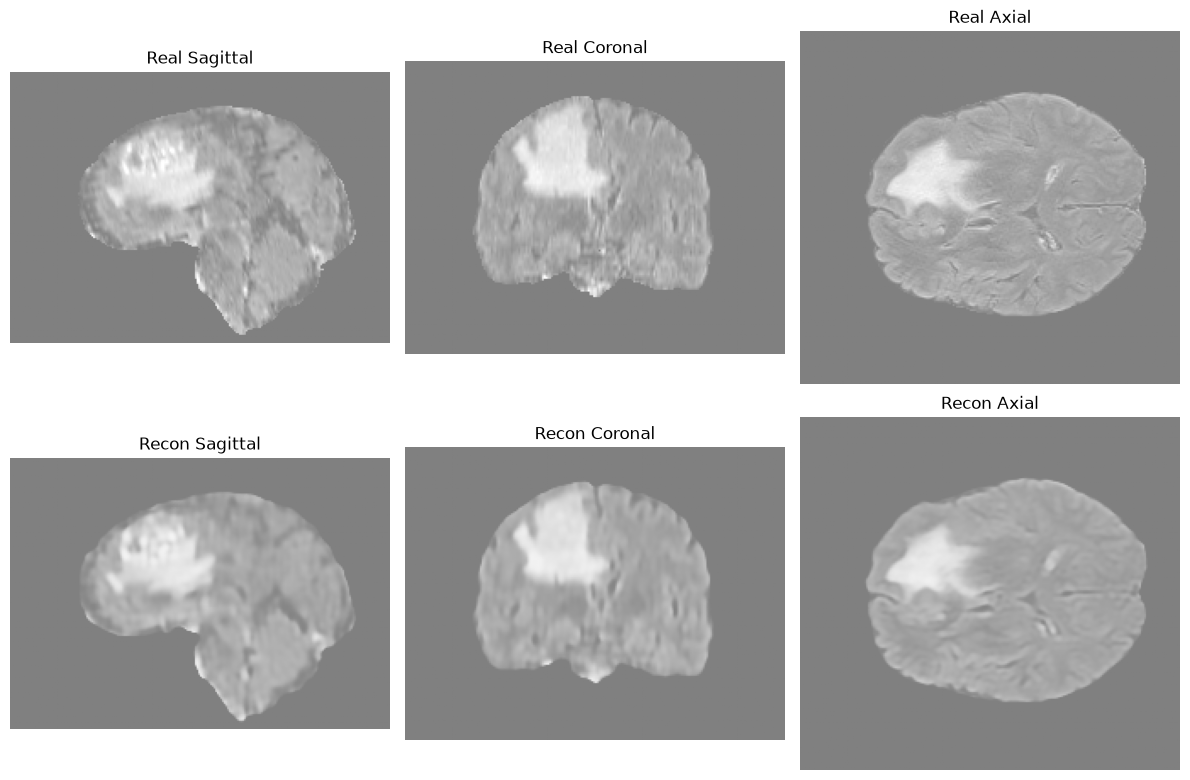


Real statistics
Mean: 0.06608931
Std: 0.15293138

Reconstruction statistics
Mean: 0.06634949
Std: 0.15098406


In [14]:
# ============================================================
# VAE V3 Epoch-15 Reconstruction Test
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)


# ------------------------------------------------------------
# 2. Re-create VAE
# ------------------------------------------------------------

vae_test = VAE3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    latent_channels=4
).to(device)


# ------------------------------------------------------------
# 3. Load VAE V3 epoch 15
# ------------------------------------------------------------

checkpoint_path = (
    "vae_x4_v3_checkpoints/"
    "vae_v3_epoch_015.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

vae_test.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

print(
    "Loaded VAE epoch:",
    checkpoint["epoch"]
)

vae_test.eval()


# ------------------------------------------------------------
# 4. Load one real MRI
# ------------------------------------------------------------

sample = train_dataset[0]

real_image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

print(
    "Subject:",
    sample["subject"]
)

print(
    "Input shape:",
    real_image.shape
)

print(
    "Input range:",
    real_image.min().item(),
    real_image.max().item()
)


# ------------------------------------------------------------
# 5. Encode + decode
# ------------------------------------------------------------

with torch.no_grad():

    reconstruction, mu, logvar, z = (
        vae_test(
            real_image
        )
    )


print(
    "Latent shape:",
    z.shape
)

print(
    "Reconstruction shape:",
    reconstruction.shape
)

print(
    "Reconstruction range:",
    reconstruction.min().item(),
    reconstruction.max().item()
)


# ------------------------------------------------------------
# 6. Metrics
# ------------------------------------------------------------

l1 = F.l1_loss(
    reconstruction,
    real_image
).item()

mse = F.mse_loss(
    reconstruction,
    real_image
).item()


# PSNR assuming [-1,1], data range = 2
psnr = (
    10.0
    * np.log10(
        (2.0 ** 2)
        / max(
            mse,
            1e-12
        )
    )
)


foreground_mask = (
    real_image > -0.999
)

foreground_l1 = (
    torch.abs(
        reconstruction[
            foreground_mask
        ]
        - real_image[
            foreground_mask
        ]
    )
    .mean()
    .item()
)


print()
print(
    "Reconstruction metrics"
)

print(
    "L1:",
    l1
)

print(
    "MSE:",
    mse
)

print(
    "PSNR:",
    psnr,
    "dB"
)

print(
    "Foreground L1:",
    foreground_l1
)


# ------------------------------------------------------------
# 7. Convert [-1,1] -> [0,1]
# ------------------------------------------------------------

real_np = (
    real_image[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

recon_np = (
    reconstruction[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


real_display = np.clip(
    (
        real_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)

recon_display = np.clip(
    (
        recon_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)

error_display = np.abs(
    real_display
    - recon_display
)


# ------------------------------------------------------------
# 8. Pick informative axial slice
# ------------------------------------------------------------

foreground_np = (
    real_display > 0
)

foreground_per_slice = (
    foreground_np.sum(
        axis=(0, 1)
    )
)

z_slice = int(
    np.argmax(
        foreground_per_slice
    )
)

print(
    "Selected axial slice:",
    z_slice
)


# ------------------------------------------------------------
# 9. Real / Reconstruction / Error
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 5)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    real_display[
        :,
        :,
        z_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Real T2f"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    recon_display[
        :,
        :,
        z_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "VAE V3 Reconstruction"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    error_display[
        :,
        :,
        z_slice
    ],
    cmap="hot",
    vmin=0,
    vmax=max(
        error_display.max(),
        1e-6
    )
)

plt.title(
    "Absolute Error"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 10. Orthogonal comparison
# ------------------------------------------------------------

x_mid = (
    real_display.shape[0]
    // 2
)

y_mid = (
    real_display.shape[1]
    // 2
)

z_mid = (
    real_display.shape[2]
    // 2
)


plt.figure(
    figsize=(12, 8)
)


# Real sagittal
plt.subplot(
    2,
    3,
    1
)

plt.imshow(
    real_display[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Real Sagittal"
)

plt.axis(
    "off"
)


# Real coronal
plt.subplot(
    2,
    3,
    2
)

plt.imshow(
    real_display[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Real Coronal"
)

plt.axis(
    "off"
)


# Real axial
plt.subplot(
    2,
    3,
    3
)

plt.imshow(
    real_display[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Real Axial"
)

plt.axis(
    "off"
)


# Recon sagittal
plt.subplot(
    2,
    3,
    4
)

plt.imshow(
    recon_display[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Recon Sagittal"
)

plt.axis(
    "off"
)


# Recon coronal
plt.subplot(
    2,
    3,
    5
)

plt.imshow(
    recon_display[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Recon Coronal"
)

plt.axis(
    "off"
)


# Recon axial
plt.subplot(
    2,
    3,
    6
)

plt.imshow(
    recon_display[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Recon Axial"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. Statistics
# ------------------------------------------------------------

print()
print(
    "Real statistics"
)

print(
    "Mean:",
    real_np.mean()
)

print(
    "Std:",
    real_np.std()
)


print()
print(
    "Reconstruction statistics"
)

print(
    "Mean:",
    recon_np.mean()
)

print(
    "Std:",
    recon_np.std()
)